# 03 - Real World: IT-Grundschutz PDF -> JSON -> Qdrant -> RAG

In this notebook we build a complete, real-world ingestion and retrieval pipeline around an actual document:
- `notebooks/raw_data/standard_200_1.pdf` (BSI IT-Grundschutz Standard 200-1)

**What is this actually about?** Imagine you want to ask a language model questions about a document it has never seen — an internal policy, say. **RAG** (Retrieval-Augmented Generation) solves this like an open-book test: before answering, the model gets to look things up in our documents instead of guessing from memory. For that to work, we first have to prepare the document so that a computer can search it precisely.

The road to get there, step by step:

<img src="img/w2_03_pipeline.svg" alt="The RAG pipeline: PDF, Docling, chunking, embeddings, Qdrant, cited answer" style="max-width:100%; width:860px">

Why this workflow?
- **Docling** extracts structured content from complex PDFs.
- **Normalization** fixes typical OCR/encoding artifacts (e.g. `/C231` instead of `ü`).
- **Chunking** makes content digestible for embeddings and semantic search — we compare **five strategies**, from simple (Markdown headings) to advanced (token-aware, semantic).
- **Metadata** makes every hit traceable (source, strategy, parameters).
- **Page numbers from JSON (`prov.page_no`)** enable reliable citations and better source references.

**What you will be able to do by the end of this notebook:**
1. Turn a real PDF into clean, searchable text
2. Explain five chunking strategies and pick one with good reasons
3. Run RAG queries with reliable citations (page numbers!)
4. Compare chunking strategies systematically — and experiment yourself in three exercises

## 1) Configuration (paths, collection, chunk parameters)

Before we start, we set all the **tuning knobs** of the pipeline in one place — like in cooking, where you first measure out and lay out all your ingredients. The benefit: anyone who wants to experiment later (smaller chunks? a different model?) changes exactly one value up here instead of hunting through the whole codebase.

Why these parameters matter:
- `MAX_CHUNK`: maximum number of characters per chunk (context window / embedding quality).
- `OVERLAP`: overlap between chunks to reduce loss of context at chunk boundaries.
- `COLLECTION_NAME`: the target **collection** in Qdrant — essentially the drawer in the database where all chunks of this experiment are stored.
- `OPENAI_API_KEY`: required for LiteLLM embeddings (from `notebooks/.env`).

In [1]:
from pathlib import Path
import json
import os
import re
from typing import List

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
RAW_DIR = NOTEBOOKS_DIR / 'raw_data'
OUT_DIR = NOTEBOOKS_DIR / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load .env from notebooks/ (if present)
env_path = NOTEBOOKS_DIR / '.env'
if env_path.exists():
    for line in env_path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip())

PDF_PATH = RAW_DIR / 'standard_200_1.pdf'

COLLECTION_NAME = 'it_grundschutz_docling'
QDRANT_HOST = 'localhost'
QDRANT_PORT = 6333

# LiteLLM/OpenAI embedding model
EMBED_MODEL_NAME = 'openai/octen-embedding-8b'
LLM_MODEL_NAME = 'openai/gpt-oss-120b'
API_BASE_URL = os.getenv('OPENAI_API_BASE', 'https://api.aisc.hpi.de/')

MAX_CHUNK = 1200
OVERLAP = 200

print('PDF:', PDF_PATH)
print('PDF exists:', PDF_PATH.exists())
print('OUT_DIR:', OUT_DIR)
print('Collection:', COLLECTION_NAME)
print('Embedding model:', EMBED_MODEL_NAME)
print('LLM model:', LLM_MODEL_NAME)
print('API base URL:', API_BASE_URL)
print('OPENAI_API_KEY set:', bool(os.getenv('OPENAI_API_KEY')))
print('MAX_CHUNK:', MAX_CHUNK, '| OVERLAP:', OVERLAP)


PDF: /Users/felixboelter/Documents/GitHub/workshop-ragV2/notebooks/raw_data/standard_200_1.pdf
PDF exists: True
OUT_DIR: /Users/felixboelter/Documents/GitHub/workshop-ragV2/notebooks/processed
Collection: it_grundschutz_docling
Embedding model: openai/octen-embedding-8b
LLM model: openai/gpt-oss-120b
API base URL: https://api.aisc.hpi.de/
OPENAI_API_KEY set: True
MAX_CHUNK: 1200 | OVERLAP: 200


In [2]:
if not PDF_PATH.exists():
    raise FileNotFoundError(f'PDF not found: {PDF_PATH}')
print('PDF found. Ready for Docling conversion.')


PDF found. Ready for Docling conversion.


## 2) Text normalization and chunking building blocks

Text extracted from a PDF is rarely perfect. It resembles a typed-up note with systematic typos: instead of `ü`, for example, you find the placeholder `/C231`. For us humans that is merely ugly — for the search step later it is fatal: a chunk containing `Schl/C231ssel` will simply never be found when someone asks about the "Schlüssel" (key). That is why we clean the text **before** processing it any further.

<img src="img/w2_03_normalization.svg" alt="A broken chunk with /C231 artifacts is not found by a search; after normalization retrieval works" style="max-width:100%; width:860px">

Here we define the core logic for improving the quality of the extracted texts:
- fixing umlaut/encoding artifacts (`/C196`, `/C231`, ...)
- JSON normalization only for content text fields (`text`, `orig`)
- parser-oriented chunking along semantic blocks (paragraph-based)

In [3]:
_UMLAUT_MAP = {
    "C196": "Ä",
    "C214": "Ö",
    "C218": "Ö",
    "C220": "Ü",
    "C216": "Ä",
    "C219": "Ü",
    "C228": "ä",
    "C229": "ä",
    "C230": "ö",
    "C231": "ü",
    "C246": "ö",
    "C252": "ü",
    "C223": "ß",
}

def _fix_german_umlauts(text: str) -> str:
    """Replace Docling/OCR placeholders like /C231 with real umlauts."""
    def repl(match: re.Match) -> str:
        code = match.group(1)
        if not code.startswith("C"):
            code = f"C{code}"
        return _UMLAUT_MAP.get(code, match.group(0))

    # Matches both /C231 and C231
    text = re.sub(r"/?(C\d{3})", repl, text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    return text

def count_umlaut_placeholders(obj) -> int:
    s = json.dumps(obj, ensure_ascii=False)
    return len(re.findall(r"/?C\d{3}", s))

def normalize_json(doc_json: dict) -> dict:
    """Normalize only content text fields, not metadata."""
    def walk(obj):
        if isinstance(obj, dict):
            out = {}
            for k, v in obj.items():
                if k in {"text", "orig"} and isinstance(v, str):
                    out[k] = _fix_german_umlauts(v)
                else:
                    out[k] = walk(v)
            return out
        if isinstance(obj, list):
            return [walk(x) for x in obj]
        return obj
    return walk(doc_json)

def normalize_text(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = _fix_german_umlauts(text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def format_citation(pages: List[int]):
    """Single source of truth for page citations — several chunking strategies below use it."""
    if not pages:
        return None
    if len(pages) == 1:
        return f'p. {pages[0]}'
    return f'p. {pages[0]}-{pages[-1]}'

# --- Chunking building blocks (used by the strategies in section 4) ---

def parser_aware_split(markdown_text: str, max_chunk: int = 1200, overlap: int = 200) -> List[str]:
    """Chunk along paragraphs; overly long blocks are split with overlap."""
    if overlap >= max_chunk:
        raise ValueError("overlap must be smaller than max_chunk")

    text = normalize_text(markdown_text)
    if not text:
        return []

    blocks = text.split("\n\n")
    chunks = []
    current = ""

    for block in blocks:
        candidate = (current + "\n\n" + block).strip() if current else block
        if len(candidate) <= max_chunk:
            current = candidate
            continue

        if current:
            chunks.append(current)

        if len(block) <= max_chunk:
            current = block
        else:
            start = 0
            while start < len(block):
                end = min(start + max_chunk, len(block))
                chunks.append(block[start:end])
                if end == len(block):
                    break
                start = end - overlap
            current = ""

    if current:
        chunks.append(current)

    if overlap > 0 and chunks:
        with_overlap = [chunks[0]]
        for i in range(1, len(chunks)):
            prefix = chunks[i - 1][-overlap:]
            with_overlap.append((prefix + "\n" + chunks[i]).strip())
        return with_overlap

    return chunks


In [4]:
# Embedding helpers (needed from here on — all later sections reuse these functions)
import numpy as np
from litellm import embedding

if not os.getenv('OPENAI_API_KEY'):
    raise ValueError('OPENAI_API_KEY is missing. Please set it in notebooks/.env.')

def _extract_embedding(item):
    if isinstance(item, dict):
        return item.get('embedding')
    return getattr(item, 'embedding', None)

def embed_texts_litellm(texts, model, batch_size=64):
    vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        resp = embedding(model=model, input=batch, api_base=API_BASE_URL, encoding_format='float')
        for item in resp.data:
            vec = _extract_embedding(item)
            if vec is None:
                raise RuntimeError('Received an embedding response without a vector.')
            vectors.append(vec)
    return vectors

# Embedding cache (same pattern as notebooks 01/02): embeddings cost time and money,
# so we store them as .npy files and reuse them on re-runs.
CACHE_DIR = Path('embedding_cache')
CACHE_DIR.mkdir(exist_ok=True)
RECREATE = False  # set True to ignore the cache and re-embed everything

def cached_embed(key: str, fn) -> np.ndarray:
    """Return cached embeddings from CACHE_DIR/<key>.npy, or compute via fn() and persist."""
    path = CACHE_DIR / f'{key}.npy'
    if path.exists() and not RECREATE:
        print(f'  [cache hit ] {path.name}')
        return np.load(path)
    print(f'  [cache miss] {path.name} — computing ...')
    arr = np.asarray(fn(), dtype=np.float32)
    np.save(path, arr)
    return arr

### What happens if we skip this step?

A tiny experiment before we move on: we embed a question about "Schlüssel" (keys) and compare it against the **same chunk twice** — once with the raw `/C231` artifacts, once normalized. Same content, very different similarity: the artifacts literally push the chunk away from the question it should answer.

In [5]:
# One question, two versions of the same chunk — only the encoding differs
demo_query = 'Wie werden Schlüssel verwaltet?'  # German query on purpose — the corpus is German
broken_chunk = 'Die Verwaltung der Schl/C231ssel und die Verschl/C231sselung sind zentrale Aufgaben des ISMS.'
clean_chunk = _fix_german_umlauts(broken_chunk)

q_vec, broken_vec, clean_vec = np.asarray(
    embed_texts_litellm([demo_query, broken_chunk, clean_chunk], model=EMBED_MODEL_NAME),
    dtype=np.float32,
)

def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

print('Chunk (broken):    ', broken_chunk)
print('Chunk (normalized):', clean_chunk)
print()
print(f'similarity(question, broken chunk):     {cos(q_vec, broken_vec):.4f}')
print(f'similarity(question, normalized chunk): {cos(q_vec, clean_vec):.4f}')

Chunk (broken):     Die Verwaltung der Schl/C231ssel und die Verschl/C231sselung sind zentrale Aufgaben des ISMS.
Chunk (normalized): Die Verwaltung der Schlüssel und die Verschlüsselung sind zentrale Aufgaben des ISMS.

similarity(question, broken chunk):     0.6236
similarity(question, normalized chunk): 0.6484


## 3) Docling conversion: PDF -> Markdown + JSON

A PDF is made for **printing**, not for machines: it stores where each letter sits on the page — but not *what* is a heading, a paragraph, or a table. **Docling** reconstructs exactly this lost structure for us, much like a person reading a printed document who automatically recognizes: "this is the chapter heading, that is a footer, these parts belong together."

We produce two artifacts:
- **Markdown**: easy to read and ideal for heading/paragraph-based chunking
- **JSON**: rich in structure (provenance, page references, bounding boxes) for deeper analyses

In [6]:
from docling.document_converter import DocumentConverter

def docling_pdf_to_markdown_and_json(pdf_path: Path):
    converter = DocumentConverter()
    result = converter.convert(str(pdf_path))
    doc = result.document

    # Optimize the Markdown for chunking/retrieval
    markdown = normalize_text(doc.export_to_markdown())

    # Load the structured JSON representation and normalize its text fields
    doc_json = doc.export_to_dict()
    before = count_umlaut_placeholders(doc_json)
    doc_json_clean = normalize_json(doc_json)
    after = count_umlaut_placeholders(doc_json_clean)

    print(f"Umlaut placeholders replaced: {before - after}")
    print(f"Remaining placeholders: {after}")
    return markdown, doc_json_clean

markdown_text, docling_json = docling_pdf_to_markdown_and_json(PDF_PATH)

markdown_out = OUT_DIR / f"{PDF_PATH.stem}.md"
json_out = OUT_DIR / f"{PDF_PATH.stem}.docling.json"
markdown_out.write_text(markdown_text, encoding="utf-8")
json_out.write_text(json.dumps(docling_json, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved markdown:", markdown_out)
print("Saved json:", json_out)
print("Markdown chars:", len(markdown_text))


objc[93328]: Class AVFFrameReceiver is implemented in both /Users/felixboelter/Documents/GitHub/workshop-ragV2/.venv-notebooks/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x31ff4c3a8) and /Users/felixboelter/Documents/GitHub/workshop-ragV2/.venv-notebooks/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x32826c3a8). One of the two will be used. Which one is undefined.
objc[93328]: Class AVFAudioReceiver is implemented in both /Users/felixboelter/Documents/GitHub/workshop-ragV2/.venv-notebooks/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x31ff4c3f8) and /Users/felixboelter/Documents/GitHub/workshop-ragV2/.venv-notebooks/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x32826c3f8). One of the two will be used. Which one is undefined.


Umlaut placeholders replaced: 2708
Remaining placeholders: 0
Saved markdown: /Users/felixboelter/Documents/GitHub/workshop-ragV2/notebooks/processed/standard_200_1.md
Saved json: /Users/felixboelter/Documents/GitHub/workshop-ragV2/notebooks/processed/standard_200_1.docling.json
Markdown chars: 127456


## 4) Chunking strategies

**Chunking** means: we cut the document into knowledge snippets — like a book we copy onto index cards. The art lies in where to cut: if the cards are too small, they lose their context; if they are too big, they cover too many topics at once and the search gets blurry. There is no universally correct cut — which is why we define several strategies and compare them head-to-head later (section 8).

<img src="img/w2_03_chunking_strategies.svg" alt="The same document cut five different ways by the five chunking strategies" style="max-width:100%; width:860px">

Our five strategies:
- `markdown_headers`: split along Markdown headings, then fine-split where needed
- `json_text_no_chunk`: no artificial chunk boundaries, one record per JSON `text` field
- `json_structured_sections`: structure-driven from Docling JSON (`content_layer`, `label`, `prov.page_no`)
- `hybrid_docling` (section 4c): Docling's built-in HybridChunker — structure-faithful **and** token-aware
- `semantic` (section 4d): chunk boundaries wherever the embedding model detects a topic shift

Important for `json_structured_sections`:
- `content_layer == "furniture"` (headers/footers/page numbers) is removed up front.
- Section labels (`section_heading`, `page_header`, ...) are the chunk boundaries.
- **No `MAX_CHUNK`, no `OVERLAP`**: a chunk runs exactly from heading to heading.
- Page information is kept as metadata and improves citations/source references.

In [7]:
import re
from typing import List, Dict, Any

def chunk_markdown_by_headers(markdown_text: str, max_chunk: int = 1200, overlap: int = 200) -> List[str]:
    """Split along Markdown headings; oversized sections are split further."""
    text = normalize_text(markdown_text)
    if not text:
        return []

    parts = re.split(r'(?m)^(#{1,6}\s.+)$', text)
    sections = []
    if parts and parts[0].strip():
        sections.append(parts[0].strip())

    for i in range(1, len(parts), 2):
        header = parts[i].strip()
        body = parts[i + 1].strip() if i + 1 < len(parts) else ""
        sections.append(f"{header}\n\n{body}".strip())

    chunks: List[str] = []
    for sec in sections:
        if len(sec) <= max_chunk:
            chunks.append(sec)
        else:
            chunks.extend(parser_aware_split(sec, max_chunk=max_chunk, overlap=overlap))

    return chunks

def records_from_markdown_header_chunks(markdown_text: str) -> List[Dict[str, Any]]:
    chunks = chunk_markdown_by_headers(markdown_text, max_chunk=MAX_CHUNK, overlap=OVERLAP)
    return [
        {
            "chunk_id": i,
            "text": chunk_text,
            "metadata": {
                "source_file": PDF_PATH.name,
                "source_path": str(PDF_PATH),
                "doc_type": "pdf",
                "converter": "docling",
                "chunking_mode": "markdown_headers",
                "max_chunk": MAX_CHUNK,
                "overlap": OVERLAP,
                "total_chunks": len(chunks),
                # Exact page numbers usually cannot be derived reliably from plain Markdown
                "page_numbers": [],
                "citation_hint": None,
            },
        }
        for i, chunk_text in enumerate(chunks)
    ]


In [8]:
def records_from_docling_json_text_fields(doc_json: dict) -> List[Dict[str, Any]]:
    """One record per JSON text field, incl. page numbers from prov.page_no."""
    items = []

    def extract_page_numbers(node: dict):
        pages = []
        prov = node.get("prov", [])
        if isinstance(prov, list):
            for p in prov:
                if isinstance(p, dict) and isinstance(p.get("page_no"), int):
                    pages.append(p["page_no"])
        return sorted(set(pages))

    def walk(obj):
        if isinstance(obj, dict):
            text_value = obj.get("text")
            if isinstance(text_value, str) and text_value.strip():
                pages = extract_page_numbers(obj)
                citation_hint = f"p. {', '.join(map(str, pages))}" if pages else None
                items.append({
                    "text": normalize_text(text_value),
                    "page_numbers": pages,
                    "citation_hint": citation_hint,
                })
            for v in obj.values():
                walk(v)
        elif isinstance(obj, list):
            for x in obj:
                walk(x)

    walk(doc_json)

    # No additional chunking/overlap: 1 record = 1 extracted text segment
    return [
        {
            "chunk_id": i,
            "text": item["text"],
            "metadata": {
                "source_file": PDF_PATH.name,
                "source_path": str(PDF_PATH),
                "doc_type": "pdf",
                "converter": "docling",
                "chunking_mode": "json_text_no_chunk",
                "max_chunk": None,
                "overlap": 0,
                "total_chunks": len(items),
                "page_numbers": item["page_numbers"],
                "citation_hint": item["citation_hint"],
            },
        }
        for i, item in enumerate(items)
    ]


## 4b) Structure-driven chunking from Docling JSON

This variant uses Docling's semantic signals directly:
- `content_layer: furniture` is discarded
- labels like `section_heading` start new semantic sections
- `prov.page_no` is stored as page metadata per chunk

Important: this variant does **not** split any further by length.
A chunk always corresponds to exactly one section from heading to heading.


In [9]:
def records_from_docling_json_structured_sections(doc_json: dict) -> List[Dict[str, Any]]:
    """Structure-driven chunks: exactly from heading to heading, no max-chunk/overlap."""
    elements = doc_json.get('texts', [])
    if not isinstance(elements, list):
        return []

    # Labels that mark a new section boundary
    heading_labels = {'section_header', 'section_heading', 'heading', 'title'}

    def extract_page_numbers(node: dict) -> List[int]:
        pages = []
        prov = node.get('prov', [])
        if isinstance(prov, list):
            for p in prov:
                if isinstance(p, dict) and isinstance(p.get('page_no'), int):
                    pages.append(p['page_no'])
        return sorted(set(pages))

    items = []
    current_heading = ''
    current_parts: List[str] = []
    current_pages: List[int] = []

    def flush_section():
        nonlocal current_parts, current_pages
        if not current_parts:
            return

        body = normalize_text(' '.join(current_parts))
        if not body:
            current_parts = []
            current_pages = []
            return

        section_text = f'{current_heading}\n\n{body}'.strip() if current_heading else body
        page_numbers = sorted(set(current_pages))

        items.append({
            'text': section_text,
            'page_numbers': page_numbers,
            'citation_hint': format_citation(page_numbers),
        })

        current_parts = []
        current_pages = []

    for el in elements:
        if not isinstance(el, dict):
            continue

        # Exclude furniture (headers/footers/page numbers)
        if el.get('content_layer') == 'furniture':
            continue

        raw_text = el.get('text') or el.get('orig') or ''
        if not isinstance(raw_text, str) or not raw_text.strip():
            continue

        text = normalize_text(raw_text)
        if not text:
            continue

        label = (el.get('label') or '').strip()
        pages = extract_page_numbers(el)

        if label in heading_labels or (label == 'page_header' and el.get('content_layer') != 'furniture'):
            flush_section()
            current_heading = text
            current_pages.extend(pages)
            continue

        current_parts.append(text)
        current_pages.extend(pages)

    flush_section()

    return [
        {
            'chunk_id': i,
            'text': item['text'],
            'metadata': {
                'source_file': PDF_PATH.name,
                'source_path': str(PDF_PATH),
                'doc_type': 'pdf',
                'converter': 'docling',
                'chunking_mode': 'json_structured_sections',
                'max_chunk': None,
                'overlap': 0,
                'total_chunks': len(items),
                'page_numbers': item['page_numbers'],
                'citation_hint': item['citation_hint'],
            },
        }
        for i, item in enumerate(items)
    ]


## 4c) Docling HybridChunker: structure-faithful + token-aware

Language models do not read text as letters but in **tokens** — word pieces that are on average about three quarters of a word long. Every embedding model has a fixed "reading budget" of tokens per chunk: if a chunk does not fit, the rest is **silently cut off** — the information is simply gone, with no error message. Our strategies so far, however, count characters rather than tokens and can only roughly estimate this budget.

<img src="img/w2_03_tokens.svg" alt="A sentence measured in characters seems to fit, but measured in tokens it overflows the 512-token budget and the tail is silently cut off" style="max-width:100%; width:860px">

Docling's `HybridChunker` solves exactly that: it first cuts along the document structure (like our 4b) and then splits or merges the sections so that every chunk is guaranteed to fit into the token budget (`max_tokens`). Page numbers and headings survive as metadata — the best of both worlds.

Two details:
- **Tokenizer as an approximation:** Our embedding model runs behind a gateway, so we do not have its real tokenizer locally. We therefore use `tiktoken` (`cl100k_base`) as a fast, decent approximation of the token budget — it does not need to be exact, just conservative enough.
- **`contextualize()`:** For the embedding, the chunker enriches the chunk text with its headings — as if every index card had the chapter it came from written at the top. We store this enriched text as `embed_text` and the plain chunk text as `text`: the enriched version gets embedded, the plain version gets displayed.

In [10]:
import tiktoken
from docling.chunking import HybridChunker
from docling_core.transforms.chunker.tokenizer.openai import OpenAITokenizer
from docling_core.types.doc.document import DoclingDocument

HYBRID_MAX_TOKENS = 512  # token budget per chunk (Exercise 1: change this value!)

_hybrid_tokenizer = OpenAITokenizer(
    tokenizer=tiktoken.get_encoding('cl100k_base'),
    max_tokens=HYBRID_MAX_TOKENS,
)
hybrid_chunker = HybridChunker(tokenizer=_hybrid_tokenizer, merge_peers=True)

# Round trip: our normalized JSON back into a DoclingDocument
doc_norm = DoclingDocument.model_validate(docling_json)

def records_from_hybrid_chunker(dl_doc) -> List[Dict[str, Any]]:
    chunks = list(hybrid_chunker.chunk(dl_doc=dl_doc))
    records = []
    for i, chunk in enumerate(chunks):
        pages = sorted({prov.page_no for item in chunk.meta.doc_items for prov in item.prov})
        headings = list(chunk.meta.headings or [])
        records.append({
            'chunk_id': i,
            'text': chunk.text,
            'embed_text': hybrid_chunker.contextualize(chunk=chunk),
            'metadata': {
                'source_file': PDF_PATH.name,
                'source_path': str(PDF_PATH),
                'doc_type': 'pdf',
                'converter': 'docling',
                'chunking_mode': 'hybrid_docling',
                'max_chunk': None,
                'max_tokens': HYBRID_MAX_TOKENS,
                'overlap': 0,
                'total_chunks': len(chunks),
                'page_numbers': pages,
                'citation_hint': format_citation(pages),
                'headings': headings,
            },
        })
    return records

hybrid_records = records_from_hybrid_chunker(doc_norm)
print('Hybrid chunks:', len(hybrid_records))

# One example: text vs. embed_text (contextualize prepends the headings)
demo = next((r for r in hybrid_records if r['metadata']['headings']), hybrid_records[0])
print('\n--- Headings:', demo['metadata']['headings'])
print('--- Pages:', demo['metadata']['page_numbers'], '|', demo['metadata']['citation_hint'])
print('\n--- text (display):\n', demo['text'][:300])
print('\n--- embed_text (for the embedding):\n', demo['embed_text'][:300])

Hybrid chunks: 123

--- Headings: ['BSI-Standard 200-1']
--- Pages: [1] | p. 1

--- text (display):
 Managementsysteme für Informationssicherheit (ISMS)

--- embed_text (for the embedding):
 BSI-Standard 200-1
Managementsysteme für Informationssicherheit (ISMS)


## 4d) Semantic chunking: boundaries at topic shifts

All strategies so far cut by the **form** of the document (paragraphs, headings, length). Semantic chunking cuts by **meaning** — like meeting minutes that you do not divide every five minutes, but at every change of topic. How does the computer know where the topic changes? It embeds every sentence individually and measures how similar neighboring sentences are. Where the similarity drops, the topic probably shifts ("topic drift") — and that is exactly where we place the chunk boundary.

<img src="img/w2_03_semantic_curve.svg" alt="Cosine similarity between neighboring sentences with a threshold; dips below it become chunk boundaries" style="max-width:100%; width:860px">

How it works:
1. Split the text into sentences (a simple regex — deliberately basic, see the note below)
2. Embed all sentences in batches (via our LiteLLM gateway)
3. Compute the cosine similarity between sentence *i* and sentence *i+1*
4. Breakpoints: all transitions whose similarity falls below the percentile threshold

**Cost note:** Unlike the other strategies, semantic chunking needs embeddings already at *chunking* time — here about 700 sentence embeddings (a few cents, under a minute via the gateway).

**A limitation as a learning point:** Our sentence splitter (`split_sentences_de`) is a simple regex, deliberately German-aware because our corpus is German (it looks for a following capital letter, including umlauts: `[A-ZÄÖÜ]`). German abbreviations like "z. B." (e.g.), "bzw." (or/respectively), or "Dr." can produce false sentence boundaries — we roughly catch that by appending very short fragments to the preceding sentence. Production-grade splitters (e.g. spaCy) handle this better. Also, we work on the Markdown text: page numbers are lost along the way. And one more caveat: a percentile threshold **always** declares the lowest X&#8202;% of transitions to be boundaries — even in passages that never change topic. The cell below therefore shows both the clearest and the weakest cut, so you can judge for yourself.

In [11]:
import numpy as np

SEMANTIC_BREAKPOINT_PERCENTILE = 20  # the lowest 20% of neighbor similarities become breakpoints

def split_sentences_de(text: str, min_len: int = 25) -> List[str]:
    """Simple German-aware sentence splitter: breaks after . ! ? when an uppercase letter/digit follows.
    Very short fragments (often abbreviation artifacts like 'z. B.') are appended to the previous sentence."""
    text = re.sub(r'(?m)^#{1,6}\s*', '', normalize_text(text))  # strip Markdown heading markers
    text = re.sub(r'\s+', ' ', text).strip()
    parts = re.split(r'(?<=[.!?])\s+(?=[A-ZÄÖÜ0-9])', text)
    sentences: List[str] = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        if sentences and len(p) < min_len:
            sentences[-1] = sentences[-1] + ' ' + p
        else:
            sentences.append(p)
    return sentences

def semantic_chunk_text(text: str,
                        percentile: float = SEMANTIC_BREAKPOINT_PERCENTILE,
                        model: str = EMBED_MODEL_NAME) -> Dict[str, Any]:
    sentences = split_sentences_de(text)
    # cached: re-running with a different percentile does NOT re-embed the sentences
    vecs = cached_embed(f'w203_sentences_{len(sentences)}',
                        lambda: embed_texts_litellm(sentences, model=model)).astype(np.float32)
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
    sims = np.sum(vecs[:-1] * vecs[1:], axis=1)         # cosine similarity sentence i <-> i+1
    threshold = float(np.percentile(sims, percentile))
    breakpoints = [i for i, s in enumerate(sims) if s < threshold]
    chunks, start = [], 0
    for bp in breakpoints:
        chunks.append(' '.join(sentences[start:bp + 1]))
        start = bp + 1
    chunks.append(' '.join(sentences[start:]))
    return {'chunks': chunks, 'sentences': sentences, 'similarities': sims,
            'threshold': threshold, 'breakpoints': breakpoints, 'percentile': percentile}

def records_from_semantic_chunks(result: Dict[str, Any]) -> List[Dict[str, Any]]:
    chunks = result['chunks']
    return [
        {
            'chunk_id': i,
            'text': chunk_text,
            'metadata': {
                'source_file': PDF_PATH.name,
                'source_path': str(PDF_PATH),
                'doc_type': 'pdf',
                'converter': 'docling',
                'chunking_mode': 'semantic',
                'max_chunk': None,
                'overlap': 0,
                'breakpoint_percentile': result['percentile'],
                'total_chunks': len(chunks),
                'page_numbers': [],   # Markdown-based: no reliable page mapping
                'citation_hint': None,
            },
        }
        for i, chunk_text in enumerate(chunks)
    ]

In [12]:
# How the sentence splitter fails — and how the heuristic patches it.
# (A workshop approximation, not a production splitter: spaCy & Co. handle this properly.)
demo = 'Die Maßnahmen sind z. B. hier beschrieben. Weitere Details folgen im Anhang.'

print('Naive split (min_len=1):')
for s in split_sentences_de(demo, min_len=1):
    print('  |', s)

print('\nWith the min_len heuristic (default — tiny fragments get merged back):')
for s in split_sentences_de(demo):
    print('  |', s)

print('\nNote: the heuristic only catches SHORT fragments — a longer clause after')
print('an abbreviation would still be split wrongly. Good enough for a workshop,')
print('not for production.')

Naive split (min_len=1):
  | Die Maßnahmen sind z.
  | B. hier beschrieben.
  | Weitere Details folgen im Anhang.

With the min_len heuristic (default — tiny fragments get merged back):
  | Die Maßnahmen sind z. B. hier beschrieben.
  | Weitere Details folgen im Anhang.

Note: the heuristic only catches SHORT fragments — a longer clause after
an abbreviation would still be split wrongly. Good enough for a workshop,
not for production.


In [ ]:
import matplotlib.pyplot as plt

# Note: this call embeds all sentences (once — the result is cached
# in 'semantic_result' and reused later)
semantic_result = semantic_chunk_text(markdown_text)

print('Sentences:   ', len(semantic_result['sentences']))
print('Breakpoints: ', len(semantic_result['breakpoints']))
print('Chunks:      ', len(semantic_result['chunks']))

sims = semantic_result['similarities']
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sims, linewidth=1, label='Cosine similarity of neighboring sentences')
ax.axhline(semantic_result['threshold'], color='red', linestyle='--',
           label=f"Threshold P{semantic_result['percentile']:.0f} = {semantic_result['threshold']:.3f}")
for bp in semantic_result['breakpoints']:
    ax.axvline(bp, color='orange', alpha=0.2, linewidth=0.8)
ax.set_xlabel('Sentence index')
ax.set_ylabel('Cosine similarity')
ax.set_title('Semantic chunking: similarity curve and breakpoints (orange)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# What actually happens at the breakpoints? Two instructive examples:
# the CLEAREST cut (lowest similarity) and the WEAKEST one (barely under the threshold).
import html
from IPython.display import HTML, display

def breakpoint_card(bp: int, label: str) -> str:
    s_before = html.escape(semantic_result['sentences'][bp][:300])
    s_after = html.escape(semantic_result['sentences'][bp + 1][:300])
    chip = ('display:inline-block;padding:0 7px;border-radius:9px;font-size:11px;'
            'background:#fff1e5;color:#bc4c00;margin-left:6px;')
    return (
        f'<div style="border:1px solid #8b949e55;border-radius:8px;overflow:hidden;">'
        f'<div style="padding:6px 10px;font-size:12px;font-weight:600;'
        f'border-bottom:1px solid #8b949e55;">{label}'
        f'<span style="{chip}">similarity {semantic_result["similarities"][bp]:.3f}</span></div>'
        f'<div style="padding:8px 10px;font-size:12.5px;line-height:1.5;">{s_before}…</div>'
        f'<div style="border-top:2px dashed #bc4c00;margin:6px 10px;position:relative;">'
        f'<span style="position:absolute;top:-9px;left:8px;background:#fff1e5;color:#bc4c00;'
        f'font-size:10px;padding:0 6px;border-radius:8px;">✂ chunk boundary</span></div>'
        f'<div style="padding:12px 10px 8px;font-size:12.5px;line-height:1.5;">{s_after}…</div></div>'
    )

bps_by_similarity = sorted(semantic_result['breakpoints'], key=lambda b: sims[b])
display(HTML(
    '<div style="font-family:system-ui,sans-serif;margin:10px 0;">'
    '<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(320px,1fr));gap:12px;">'
    + breakpoint_card(bps_by_similarity[0], 'Clearest cut — a convincing topic shift')
    + breakpoint_card(bps_by_similarity[-1], 'Weakest cut — barely under the threshold')
    + '</div>'
    f'<div style="font-size:12px;opacity:0.7;margin-top:8px;">'
    f'Not every cut is a real topic change: the percentile threshold <b>always</b> turns the '
    f'lowest {semantic_result["percentile"]:.0f}&#8202;% of transitions into boundaries — even '
    f'between sentences that clearly belong together (the weakest cuts often split a statement '
    f'from its example). A known weakness of simple semantic chunking, and a good reason to '
    f'eyeball the breakpoints instead of trusting the plot alone.</div></div>'
))

**What you are looking at — the "cut by meaning" moment.** The plot is the mechanism: similarity between neighboring sentences, and every dip below the threshold becomes a chunk boundary. The two cards show its extremes. The *clearest* cut usually lands on a real transition — often rediscovering a chapter boundary that the structure-based strategies get for free from the headings (semantic chunking earns its keep on text *without* such structure). The *weakest* cut is a judgment call that may split related content — and that has a real RAG cost: the answer to one question can end up spread across two chunks, so retrieval returns only half the picture (exactly what the parent-child pattern in Exercise 3 repairs).

Don't confuse the two "semantics" in this notebook: **semantic chunking** cuts the document by meaning at *ingestion* time (here), while **semantic search** finds chunks by meaning at *query* time (section 6). They use the same embedding model but are independent steps — section 8 pairs semantic search with all five chunking strategies.

**Cross-check with the HybridChunker:** the structure gives us a second opinion on both cuts. The next cell looks up the two example sentences inside the `hybrid_docling` chunks from section 4c and checks: does the structure-aware strategy cut at the same spot? Typically the *clearest* semantic cut coincides with a heading boundary (both strategies cut — meaning and structure agree), while the *weakest* cut lies inside a section (the HybridChunker keeps the text together). Where the two disagree, you are looking at exactly the trade-off between cutting by meaning and cutting by structure.

In [53]:
# Does the structure-aware HybridChunker cut at the same spots as the semantic strategy?
from difflib import SequenceMatcher

def _find_hybrid_chunk(sentence: str):
    """Locate the hybrid chunk containing the sentence (fuzzy — the two texts
    come from different export paths and may differ in whitespace/details)."""
    probe = ' '.join(sentence.split()).lower()[:80]
    best = (0, -1)
    for i, r in enumerate(hybrid_records):
        hay = ' '.join(r['text'].split()).lower()
        m = SequenceMatcher(None, probe, hay, autojunk=False).find_longest_match(0, len(probe), 0, len(hay))
        if m.size > best[1]:
            best = (i, m.size)
    return hybrid_records[best[0]]

def compare_cut_with_hybrid(bp: int, label: str) -> str:
    chip_o = ('display:inline-block;padding:0 7px;border-radius:9px;font-size:11px;'
              'background:#fff1e5;color:#bc4c00;margin-right:4px;')
    chip_g = chip_o.replace('#fff1e5', '#dafbe1').replace('#bc4c00', '#1a7f37')
    r_before = _find_hybrid_chunk(semantic_result['sentences'][bp])
    r_after = _find_hybrid_chunk(semantic_result['sentences'][bp + 1])
    row = 'padding:6px 10px;font-size:12.5px;border-top:1px solid #8b949e40;'
    if r_before['chunk_id'] == r_after['chunk_id']:
        verdict = (f'<span style="{chip_g}">keeps both sentences in ONE chunk</span> '
                   f'<span style="opacity:0.65;">#{r_before["chunk_id"]} · '
                   f'headings: {", ".join(r_before["metadata"]["headings"]) or "–"}</span>'
                   f'<div style="font-size:11.5px;opacity:0.65;margin-top:2px;">→ the structure '
                   f'says this is one section — the semantic cut here splits related content.</div>')
    else:
        verdict = (f'<span style="{chip_o}">also cuts here</span> '
                   f'<span style="opacity:0.65;">chunk #{r_before["chunk_id"]} '
                   f'(headings: {", ".join(r_before["metadata"]["headings"]) or "–"}) → '
                   f'chunk #{r_after["chunk_id"]} '
                   f'(headings: {", ".join(r_after["metadata"]["headings"]) or "–"})</span>'
                   f'<div style="font-size:11.5px;opacity:0.65;margin-top:2px;">→ meaning and '
                   f'structure agree: a real boundary.</div>')
    return (
        f'<div style="border:1px solid #8b949e55;border-radius:8px;overflow:hidden;">'
        f'<div style="padding:6px 10px;font-size:12px;font-weight:600;">{label} '
        f'<span style="{chip_o}">similarity {semantic_result["similarities"][bp]:.3f}</span></div>'
        f'<div style="{row}"><b style="font-size:11px;">semantic</b> — '
        f'<span style="{chip_o}">cuts here (by definition)</span></div>'
        f'<div style="{row}"><b style="font-size:11px;">hybrid_docling</b> — {verdict}</div></div>'
    )

bps_by_similarity = sorted(semantic_result['breakpoints'], key=lambda b: semantic_result['similarities'][b])
display(HTML(
    '<div style="display:grid;gap:12px;margin:10px 0;font-family:system-ui,sans-serif;">'
    + compare_cut_with_hybrid(bps_by_similarity[0], 'Clearest semantic cut')
    + compare_cut_with_hybrid(bps_by_similarity[-1], 'Weakest semantic cut')
    + '</div>'
))

## 4e) Choose a strategy and create the `records`

Five strategies are now on the table — but we start by loading exactly one of them into the database. This is where the decision happens: `CHUNKING_MODE` determines which chunks actually end up in Qdrant. The chosen mode is stored in each chunk's metadata (`chunking_mode`), so you can always trace later how a hit came to be.

New: `hybrid_docling` and `semantic` are now available as options too. Records may optionally carry an `embed_text` field — in that case this text gets embedded, while `text` is used for display and LLM context (see `contextualize()` in 4c).

We pick one strategy here to walk the full pipeline end-to-end. In section 8 we then compare all five side by side — you do **not** need to re-run the notebook once per strategy.

In [14]:
# Options: 'markdown_headers' | 'json_text_no_chunk' | 'json_structured_sections' | 'hybrid_docling' | 'semantic'
CHUNKING_MODE = 'json_structured_sections'

if CHUNKING_MODE == 'markdown_headers':
    records = records_from_markdown_header_chunks(markdown_text)
elif CHUNKING_MODE == 'json_text_no_chunk':
    records = records_from_docling_json_text_fields(docling_json)
elif CHUNKING_MODE == 'json_structured_sections':
    records = records_from_docling_json_structured_sections(docling_json)
elif CHUNKING_MODE == 'hybrid_docling':
    records = records_from_hybrid_chunker(doc_norm)
elif CHUNKING_MODE == 'semantic':
    records = records_from_semantic_chunks(semantic_result)
else:
    raise ValueError(f'Unknown CHUNKING_MODE: {CHUNKING_MODE}')

chunks_out = OUT_DIR / f'{PDF_PATH.stem}.{CHUNKING_MODE}.chunks.json'
chunks_out.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding='utf-8')

print('Chunking mode:', CHUNKING_MODE)
print('Number of records:', len(records))
print('Saved chunks:', chunks_out)
if records:
    print('\nPreview record 0:\n')
    print(records[0]['text'][:800])
    print('Pages:', records[0]['metadata'].get('page_numbers'))
    print('Citation:', records[0]['metadata'].get('citation_hint'))

Chunking mode: json_structured_sections
Number of records: 87
Saved chunks: /Users/felixboelter/Documents/GitHub/workshop-ragV2/notebooks/processed/standard_200_1.json_structured_sections.chunks.json

Preview record 0:

BSI-Standard 200-1

Managementsysteme für Informationssicherheit (ISMS)
Pages: [1]
Citation: p. 1


## 5) Embeddings with LiteLLM + upload to Qdrant

Now we make the chunks searchable. An **embedding** turns a text into a long row of numbers — you can picture it as a point on a "map of meanings": things that are similar in content sit close together ("Hund" (dog) next to "Welpe" (puppy)), unrelated things sit far apart ("Hund" far away from "Steuererklärung" (tax return)). **Qdrant** is a database specialized in exactly one job: given a point, finding its nearest neighbors on this map at lightning speed.

Technical details:
- We use LiteLLM as a unified API for embeddings — switching models/providers then requires only minimal code changes.
- If a record has an `embed_text` field (e.g. with `hybrid_docling`), that text gets embedded; `text` remains the display/LLM text.
- The upload happens in batches so that Qdrant's request-size limits are not exceeded.

In [16]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

def batched(iterable, batch_size):
    for i in range(0, len(iterable), batch_size):
        yield iterable[i:i+batch_size]

client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)

# 'embed_text' (if present, e.g. with hybrid_docling) gets embedded; 'text' remains the display/LLM text
texts = [r.get('embed_text', r['text']) for r in records]
vectors = cached_embed(f'w203_main_{CHUNKING_MODE}_{len(texts)}',
                       lambda: embed_texts_litellm(texts, model=EMBED_MODEL_NAME)).tolist()
vector_size = len(vectors[0])

# New API instead of the deprecated recreate_collection
if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)
client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE),
)

points = []
for r, vec in zip(records, vectors):
    payload = {
        'text': r['text'],
        **r['metadata'],
        'chunk_id': r['chunk_id'],
    }
    points.append(PointStruct(id=r['chunk_id'], vector=vec, payload=payload))

# Batch upload to stay under the request-size limit (32MB)
UPSERT_BATCH_SIZE = 64
for batch_idx, batch_points in enumerate(batched(points, UPSERT_BATCH_SIZE), start=1):
    client.upsert(collection_name=COLLECTION_NAME, points=batch_points)
    print(f'Uploaded batch {batch_idx} ({len(batch_points)} points)')

info = client.get_collection(COLLECTION_NAME)
print('Collection ready:', COLLECTION_NAME)
print('Vectors count:', info.points_count)
print('Vector size:', vector_size)
print('Total points uploaded:', len(points))

/var/folders/xx/_1vpf06s35sd5ms16ydz8jhm0000gn/T/ipykernel_93328/2689845166.py:8: UserWarning: Qdrant client version 1.16.2 is incompatible with server version 1.18.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)


  [cache hit ] w203_main_json_structured_sections_87.npy
Uploaded batch 1 (64 points)
Uploaded batch 2 (23 points)
Collection ready: it_grundschutz_docling
Vectors count: 87
Vector size: 4096
Total points uploaded: 87


In [17]:
# Sanity check: pull one chunk back out of Qdrant — did the upload preserve the payload?
sample = client.retrieve(collection_name=COLLECTION_NAME, ids=[0], with_payload=True)[0]
print('chunk_id:', sample.payload.get('chunk_id'))
print('pages:   ', sample.payload.get('page_numbers'), '|', sample.payload.get('citation_hint'))
print('mode:    ', sample.payload.get('chunking_mode'))
print('text:    ', (sample.payload.get('text') or '')[:300].replace('\n', ' '))

chunk_id: 0
pages:    [1] | p. 1
mode:     json_structured_sections
text:     BSI-Standard 200-1  Managementsysteme für Informationssicherheit (ISMS)


## 6) RAG query demo: semantic search vs keyword search

Semantic search works fundamentally differently from Ctrl+F: it compares **meaning**, not letters. A question about "Verantwortung der Geschäftsführung" (responsibility of executive management) also finds chunks that literally only talk about "Pflichten der Leitungsebene" (duties of the management level) — because both phrasings sit close together on the map of meanings. To do this, the question is turned into a point with the same embedding model, and Qdrant returns the closest chunks.

We search for chunks semantically similar to the user question and show the top hits with a score — the **score** (0 to 1) measures how close a chunk is to the question on the map.

In [18]:
def rag_search(query: str, top_k: int = 5):
    q_vec = embed_texts_litellm([query], model=EMBED_MODEL_NAME)[0]
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        query=q_vec,
        limit=top_k,
        with_payload=True,
        with_vectors=False,
    )

    hits = response.points
    results = []
    for h in hits:
        payload = h.payload or {}
        results.append({
            'score': h.score,
            'chunk_id': payload.get('chunk_id'),
            'text': payload.get('text', ''),
            'source_file': payload.get('source_file'),
            'page_numbers': payload.get('page_numbers', []),
            'citation_hint': payload.get('citation_hint'),
        })
    return results

# German query on purpose — the corpus is German
query = 'Welche Anforderungen stellt der Standard an Informationssicherheit und Risikomanagement?'
hits = rag_search(query, top_k=5)

import html
from IPython.display import HTML, display

def show_hits(query: str, hits) -> None:
    """Render retrieval hits as cards: score/pages chips up top, chunk text below."""
    chip = ('display:inline-block;padding:1px 8px;border-radius:10px;font-size:11px;'
            'background:#ddf4ff;color:#0969da;margin-right:6px;')
    cards = []
    for i, h in enumerate(hits, start=1):
        pages = ', '.join(map(str, h['page_numbers'])) if h['page_numbers'] else '–'
        cite = h['citation_hint'] or '–'
        body = html.escape(h['text'])
        cards.append(
            f'<div style="border:1px solid #8b949e55;border-radius:8px;overflow:hidden;">'
            f'<div style="padding:6px 12px;border-bottom:1px solid #8b949e55;font-size:12px;">'
            f'<b>#{i}</b>&nbsp; <span style="{chip}">score {h["score"]:.3f}</span>'
            f'<span style="{chip}">pages {pages}</span>'
            f'<span style="{chip}">{cite}</span>'
            f'<span style="opacity:0.6;">chunk {h["chunk_id"]} · {h["source_file"]}</span></div>'
            f'<div style="padding:10px 12px;max-height:180px;overflow:auto;font-size:13px;'
            f'line-height:1.5;white-space:pre-wrap;">{body}</div></div>'
        )
    display(HTML(
        f'<div style="font-family:system-ui,sans-serif;">'
        f'<div style="font-size:13px;margin:4px 0 10px;"><b>Query:</b> '
        f'<code>{html.escape(query)}</code></div>'
        f'<div style="display:grid;gap:10px;">{"".join(cards)}</div></div>'
    ))

show_hits(query, hits)


## 7) RAG + LLM answer with LiteLLM

Up to this point we have only *retrieved* — now we let the model *answer*. This is the "open-book" moment: we hand the language model the retrieved passages as context and instruct it to answer **only** on that basis and to list the page numbers as sources at the end. That keeps every answer verifiable — anyone in doubt can look up the cited page in the original. This is exactly what separates RAG from a model answering freely from memory (which can hallucinate).

Technically: a context is built from the top retrieval hits and sent to a chat LLM.
Default model: `openai/gpt-oss-120b` (via your LiteLLM gateway).
If your deployment uses a different name, set `LLM_MODEL_NAME` accordingly in `.env`.

In [19]:
from litellm import completion
from IPython.display import Markdown, display


# max_chars_per_chunk keeps the prompt inside the LLM's practical context window —
# over-stuffing the context can actually degrade answer quality.
def build_rag_context(hits, max_chars_per_chunk: int = 1400) -> str:
    blocks = []
    for i, h in enumerate(hits, start=1):
        pages = h.get('page_numbers') or []
        cite = h.get('citation_hint') or '-'
        pages_text = ', '.join(map(str, pages)) if pages else '-'
        snippet = (h.get('text') or '')[:max_chars_per_chunk]
        blocks.append(
            f"[Source {i}] score={h['score']:.4f} | pages={pages_text} | cite={cite}\n{snippet}"
        )
    return '\n\n'.join(blocks)

def answer_with_llm(query: str, hits, model: str = None) -> str:
    model = model or LLM_MODEL_NAME
    context = build_rag_context(hits)

    system_prompt = (
        'You are a RAG assistant for IT-Grundschutz. '
        'Answer only based on the provided context. '
        'If the information is missing, say so clearly. '
        'List the sources with page numbers at the end. '
        'Answer in the language of the question.'
    )

    user_prompt = f"Question:\n{query}\n\nContext:\n{context}"

    resp = completion(
        model=model,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt},
        ],
        api_base=API_BASE_URL,
        api_key=os.getenv('OPENAI_API_KEY'),
        temperature=0.2,
    )

    return resp.choices[0].message.content

llm_answer = answer_with_llm(query, hits)
print('LLM answer:\n')
display(Markdown(llm_answer))


LLM answer:



**Anforderungen des BSI‑Standards 200‑1 an Informationssicherheit und Risikomanagement**

| Anforderung | Beschreibung (nach den vorliegenden Quellen) |
|-------------|----------------------------------------------|
| **Allgemeine ISMS‑Anforderungen** | Der Standard definiert allgemeine Anforderungen an ein Informations‑Sicherheits‑Managementsystem (ISMS). Er beschreibt, mit welchen **Methoden** Informationssicherheit in einer Institution **initiiert, gesteuert und überwacht** werden kann. (Quelle 5, S. 12) |
| **Kompatibilität zu internationalen Normen** | Der Standard ist vollständig kompatibel zu **ISO/IEC 27001** und berücksichtigt die Begriffe aus **ISO/IEC 27000** sowie die Empfehlungen der **ISO/IEC 27002**. (Quelle 5, S. 12) |
| **Leitungsebene & Steuerungsinstrumente** | Das ISMS legt fest, welche **Instrumente und Methoden** die Leitungsebene nutzen muss, um sicherheitsrelevante Aufgaben nachvollziehbar zu lenken. (Quelle 2, S. 7) |
| **Entwicklung von Sicherheitszielen & -strategie** | Es muss eine **Sicherheitsstrategie** entwickelt und konkrete **Sicherheitsziele** definiert werden. (Quelle 2, S. 7) |
| **Risikomanagement** | Der Standard verlangt ein **Risikomanagement**, das sich an den Rahmenempfehlungen von **ISO/IEC 27005** (bzw. ISO 31000/31010) orientiert: Risiken müssen identifiziert, eingeschätzt, bewertet und behandelt werden. (Quelle 3, S. 9‑10) |
| **Auswahl und Umsetzung von Sicherheitsmaßnahmen** | Auf Basis der Risiko‑Analyse sind geeignete **Sicherheitsmaßnahmen** auszuwählen und ein **Sicherheitskonzept** zu erstellen. (Quelle 2, S. 7) |
| **Kontinuierliche Überwachung und Verbesserung** | Das erreichte Sicherheitsniveau muss **dauerhaft erhalten und kontinuierlich verbessert** werden (Monitoring, Audits, Management‑Reviews). (Quelle 2, S. 7) |
| **Methodik des IT‑Grundschutzes** | Die Umsetzung der genannten Anforderungen wird durch die **Methodik des IT‑Grundschutzes** unterstützt, die Schritt‑für‑Schritt‑Anleitungen für Institutionen unterschiedlicher Größe liefert. (Quelle 2, S. 7) |

**Zusammengefasst** verlangt der BSI‑Standard 200‑1, dass eine Organisation ein strukturiertes ISMS einführt, das auf international anerkannten Normen (ISO 27001/27000/27002) basiert, klare Sicherheitsziele und -strategien definiert, ein systematisches Risikomanagement (nach ISO 27005/31000) durchführt, geeignete Sicherheitsmaßnahmen auswählt, deren Umsetzung dokumentiert und überwacht sowie das Gesamtniveau kontinuierlich verbessert.  

**Quellen**  
- BSI‑Standard 200‑1, S. 12 (Quelle 5)  
- BSI‑Standard 200‑1, S. 7 (Quelle 2)  
- ISO/IEC 27005 (Risikomanagement), S. 9‑10 (Quelle 3)  

**Why the system prompt looks the way it does.** Every instruction in it earns its place:

- *"Answer only based on the provided context"* — grounding. Without it, the model happily mixes in half-remembered training knowledge (hallucinations included).
- *"If the information is missing, say so clearly"* — permission to admit ignorance. Otherwise the model would rather guess than disappoint you.
- *"List the sources with page numbers"* — verifiability. Anyone who doubts an answer can open the cited page in the original document.
- *"Answer in the language of the question"* — our corpus is German, but this notebook (and your questions) may not be.

**Try it:** remove the first instruction from `system_prompt`, re-run the cell, and compare the answers. Does the model still stick to the document?

---
## 8) Comparing the strategies

Remember the strategy you picked in section 4e? Now let's see how it stacks up against the other four. Five filing systems, the same questions: which one surfaces the best index cards? First we look at how differently the strategies cut the document (number and length of chunks) — then we ask all five the same questions and compare the hits side by side.

The approach:
1. **Chunk statistics** (free, no API calls): count and length distribution per strategy
2. **Retrieval comparison**: each strategy gets its own Qdrant collection (`it_grundschutz_cmp_<strategy>`), then all of them answer the same questions

**How to read the result — important:** a higher score does *not* mean a better strategy. Each strategy produces chunks of different lengths and embeds different text (e.g. `hybrid_docling` embeds heading-enriched text), so the cosine scores live on **different scales** — 0.70 for a one-line chunk is not better than 0.63 for a full section. Compare *within* a strategy, and judge *across* strategies by content: does the top hit actually answer the question, does it carry enough context, do the page numbers agree?

**Cost note:** the first run embeds all chunks of all five strategies (~1,500 texts, roughly 1–2 minutes via the gateway). Re-runs are nearly free: the vectors are cached in `embedding_cache/` (set `RECREATE = True` in section 2 to force re-embedding).

,chunks,chars_mean,chars_median,chars_min,chars_max
strategy,,,,,
markdown_headers,179,806,830,12,1401
json_text_no_chunk,972,137,45,1,1520
json_structured_sections,87,1353,946,28,5308
hybrid_docling,123,1048,1054,51,1941
semantic,136,931,494,40,6894


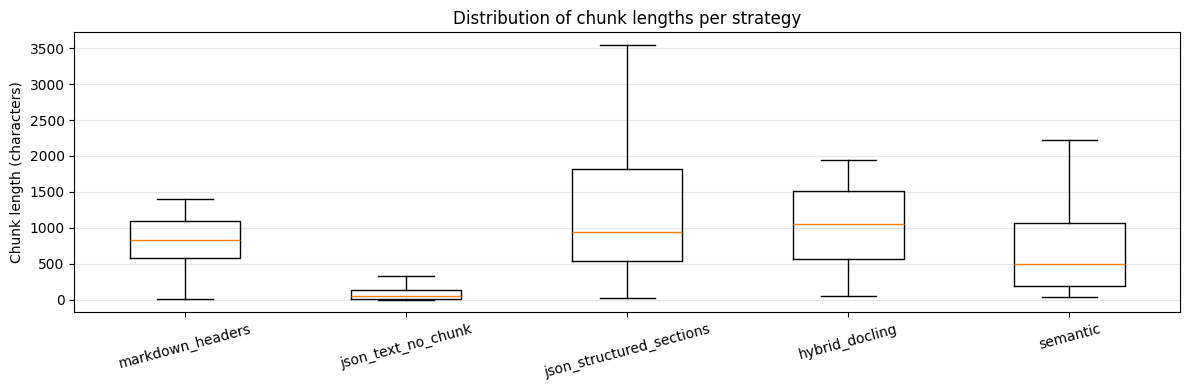

In [20]:
import pandas as pd
from statistics import mean, median

strategy_records = {
    'markdown_headers': records_from_markdown_header_chunks(markdown_text),
    'json_text_no_chunk': records_from_docling_json_text_fields(docling_json),
    'json_structured_sections': records_from_docling_json_structured_sections(docling_json),
    'hybrid_docling': records_from_hybrid_chunker(doc_norm),
    'semantic': records_from_semantic_chunks(semantic_result),  # reuses the sentence embeddings computed earlier
}

rows = []
for name, recs in strategy_records.items():
    lengths = [len(r['text']) for r in recs]
    rows.append({
        'strategy': name,
        'chunks': len(recs),
        'chars_mean': round(mean(lengths)),
        'chars_median': round(median(lengths)),
        'chars_min': min(lengths),
        'chars_max': max(lengths),
    })
df_stats = pd.DataFrame(rows).set_index('strategy')
display(df_stats)

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([[len(r['text']) for r in recs] for recs in strategy_records.values()],
           tick_labels=list(strategy_records.keys()), showfliers=False)
ax.set_ylabel('Chunk length (characters)')
ax.set_title('Distribution of chunk lengths per strategy')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
import html
from IPython.display import HTML, display

# German queries on purpose — the corpus is German
COMPARE_QUERIES = [
    'Welche Anforderungen stellt der Standard an Informationssicherheit und Risikomanagement?',
    'Welche Aufgaben und Verantwortung hat die Leitungsebene im Sicherheitsprozess?',
]
TOP_K_COMPARE = 3

def ingest_records_to_collection(recs, collection_name):
    texts = [r.get('embed_text', r['text']) for r in recs]
    # cached: the first run embeds everything, re-runs load from embedding_cache/
    vectors = cached_embed(f'w203_cmp_{collection_name}_{len(texts)}',
                           lambda: embed_texts_litellm(texts, model=EMBED_MODEL_NAME)).tolist()
    if client.collection_exists(collection_name):
        client.delete_collection(collection_name)
    client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=len(vectors[0]), distance=Distance.COSINE),
    )
    points = [
        PointStruct(id=r['chunk_id'], vector=v,
                    payload={'text': r['text'], **r['metadata'], 'chunk_id': r['chunk_id']})
        for r, v in zip(recs, vectors)
    ]
    for batch_points in batched(points, 64):
        client.upsert(collection_name=collection_name, points=batch_points)

for name, recs in strategy_records.items():
    col = f'it_grundschutz_cmp_{name}'
    print(f'Ingest {name}: {len(recs)} chunks -> {col}')
    ingest_records_to_collection(recs, col)

def compare_strategies(query: str, top_k: int = TOP_K_COMPARE) -> None:
    """One card per strategy with its top hits.
    Careful: scores are comparable only WITHIN a card, never across strategies —
    chunk length and embedded text differ, so the score scales differ too."""
    chip = ('display:inline-block;padding:0 7px;border-radius:9px;font-size:11px;'
            'background:#ddf4ff;color:#0969da;margin-right:4px;')
    q_vec = embed_texts_litellm([query], model=EMBED_MODEL_NAME)[0]
    columns = []
    for name in strategy_records:
        resp = client.query_points(collection_name=f'it_grundschutz_cmp_{name}',
                                   query=q_vec, limit=top_k, with_payload=True)
        hits_html = []
        for rank, p in enumerate(resp.points, start=1):
            payload = p.payload or {}
            text = payload.get('text') or ''
            pages = ', '.join(map(str, payload.get('page_numbers') or [])) or '–'
            border = 'border-top:1px solid #8b949e40;' if rank > 1 else ''
            hits_html.append(
                f'<div style="padding:7px 10px;{border}">'
                f'<div style="margin-bottom:3px;"><b style="font-size:11px;">#{rank}</b> '
                f'<span style="{chip}">score {p.score:.3f}</span>'
                f'<span style="{chip}">p. {pages}</span>'
                f'<span style="{chip}">{len(text):,} chars</span></div>'
                f'<div style="font-size:12px;line-height:1.45;opacity:0.9;">'
                f'{html.escape(text[:280])}…</div></div>'
            )
        columns.append(
            f'<div style="border:1px solid #8b949e55;border-radius:8px;overflow:hidden;">'
            f'<div style="padding:6px 10px;font-size:12px;font-weight:600;'
            f'border-bottom:1px solid #8b949e55;">{name} '
            f'<span style="opacity:0.55;font-weight:400;">· {len(strategy_records[name])} chunks</span></div>'
            f'{"".join(hits_html)}</div>'
        )
    display(HTML(
        f'<div style="font-family:system-ui,sans-serif;margin:10px 0 26px;">'
        f'<div style="font-size:13px;margin-bottom:4px;"><b>Query:</b> '
        f'<code>{html.escape(query)}</code></div>'
        f'<div style="font-size:12px;opacity:0.7;margin-bottom:8px;">'
        f'Scores are comparable <b>within</b> a card, not across strategies — chunk length and '
        f'embedded text differ, so the score scales differ. Judge by content: does the top hit '
        f'actually answer the question, and with enough context?</div>'
        f'<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(250px,1fr));'
        f'gap:10px;">{"".join(columns)}</div></div>'
    ))

for q in COMPARE_QUERIES:
    compare_strategies(q)

# Cleanup (optional): delete the comparison collections again
# for name in strategy_records:
#     col = f'it_grundschutz_cmp_{name}'
#     if client.collection_exists(col):
#         client.delete_collection(col)

## 9) Optional: mini chat

Time to experiment — now with everything you know about the trade-offs. Ask the document your own questions and watch the retrieved sources: can you come up with queries that expose the weaknesses of the strategy you picked in section 4e? Detail questions and broad overview questions tend to favor different chunkings — the comparison above tells you which.

Type `exit` to end the chat.

In [22]:
from IPython.display import Markdown, display

def rag_chat(turns: int = 3, top_k: int = 5):
    print("Mini chat started. Type 'exit' to quit.")
    for _ in range(turns):
        q = input("\nQuestion: ").strip()
        if q.lower() in {"exit", "quit"}:
            print("Chat ended.")
            break

        hits = rag_search(q, top_k=top_k)
        answer = answer_with_llm(q, hits, model=LLM_MODEL_NAME)

        # Render the answer as Markdown
        display(Markdown(f"### Answer\n\n{answer}"))

        # Show the sources compactly
        print("\nSources:")
        for i, h in enumerate(hits, start=1):
            pages = h.get("page_numbers") or "-"
            cite = h.get("citation_hint") or "-"
            print(f"[{i}] score={h['score']:.4f} | pages={pages} | cite={cite}")

# Start
rag_chat(turns=10, top_k=5)


Mini chat started. Type 'exit' to quit.


### Answer

Der von Ihnen übermittelte Text enthält keine konkrete Frage. Bitte stellen Sie Ihre Frage zum Thema IT‑Grundschutz, Sicherheitskonzept, Optimierung, Fehlerbehandlung oder einem anderen verwandten Aspekt, damit ich Ihnen gezielt weiterhelfen kann.


Sources:
[1] score=0.2592 | pages=[33] | cite=p. 33
[2] score=0.2587 | pages=[33] | cite=p. 33
[3] score=0.2558 | pages=[38] | cite=p. 38
[4] score=0.2557 | pages=[37] | cite=p. 37
[5] score=0.2535 | pages=[43, 44] | cite=p. 43-44


### Answer

Der von Ihnen gestellte „Question:“ enthält keinen eigentlichen Text oder eine konkrete Fragestellung. Ohne eine konkrete Frage kann ich leider keine inhaltliche Antwort geben.

Falls Sie zu den bereitgestellten Quellen (z. B. zum Lebenszyklus eines Sicherheitskonzepts, zur kontinuierlichen Verbesserung, zur Detektion von Sicherheitsvorfällen oder zu den Schritten der Sicherheitskonzeption nach IT‑Grundschutz) eine spezifische Frage haben, formulieren Sie diese bitte erneut. Dann kann ich Ihnen gezielt weiterhelfen.


Sources:
[1] score=0.2592 | pages=[33] | cite=p. 33
[2] score=0.2587 | pages=[33] | cite=p. 33
[3] score=0.2558 | pages=[38] | cite=p. 38
[4] score=0.2557 | pages=[37] | cite=p. 37
[5] score=0.2535 | pages=[43, 44] | cite=p. 43-44
Chat ended.


## 10) Recap and takeaways

You have now built a complete pipeline:
1. Extracted a PDF with Docling
2. Cleaned up encoding artifacts
3. Chosen a chunking strategy
4. Stored embeddings + metadata in Qdrant
5. Run a RAG query
6. Generated an LLM answer based on the retrieved sources
7. Compared five chunking strategies head-to-head

How the strategies stack up:
- `markdown_headers`: good for quick, robust baselines on Markdown.
- `json_text_no_chunk`: close to the raw extraction, including page references per text field.
- `json_structured_sections`: clean section boundaries (heading->heading), no artificial splitting.
- `hybrid_docling`: best balance of structure and token budget; page and heading metadata included — a good default in practice.
- `semantic`: topically coherent chunks independent of layout; but more expensive (embeddings already at chunking time) and, here, without page metadata.

**A rule of thumb that this notebook's own data supports: structure first when you have it, semantic when you don't.** The cross-check in section 4d showed it concretely: at the real chapter boundary, the semantic cut only confirmed what the headings already knew — and at its weakest cut it split a coherent section that the HybridChunker kept together, spreading the answer to one question across two chunks. On a well-structured document like this standard, `hybrid_docling` wins (and brings pages, headings, and the token budget along for free). Semantic chunking is the specialist for text *without* usable structure: transcripts, chat logs, emails, flat OCR output.

The head-to-head comparison in section 8 shows: **there is no universally best strategy.** The right choice depends on the document type (highly structured vs. running text) and on the question type (detail question vs. overview question). That is exactly why it pays off to compare strategies systematically instead of grabbing the first one that works — and that is precisely what you will practice now in the exercises.

---
## 11) Exercises

Three exercises in increasing difficulty — from "just change some values" to "build your own retrieval strategy". Pick whatever matches your level; nobody has to finish all three. Every exercise comes with a fold-out solution: **try it yourself first, then compare!**

### Exercise 1 (Easy) — Turn the knobs, watch the effect

No new code needed — just change values, re-run cells, and observe:

1. In section 4c, set `HYBRID_MAX_TOKENS = 256` (instead of 512) and re-run the cell. How does the number of hybrid chunks change?
2. In section 4d, set `SEMANTIC_BREAKPOINT_PERCENTILE = 5` (instead of 20) and re-run the cells in 4d (quick: the sentence embeddings come from the cache). What happens to the number of breakpoints in the plot?
3. Re-run the statistics cell in section 8 and compare the table with before.

At each step, take a moment to think about *why* the number changes the way it does before opening the solution.

In [23]:
# TODO: Exercise 1 — no new code needed, just change parameters and re-run cells
# 1. Change HYBRID_MAX_TOKENS in section 4c -> re-run the 4c cell
# 2. Change SEMANTIC_BREAKPOINT_PERCENTILE in section 4d -> re-run the 4d cells
# 3. Re-run the statistics cell in section 8 and compare the table with before
# Note your observations here:

<details>
<summary><b>Show solution (Exercise 1)</b></summary>

Expected observations:

- `HYBRID_MAX_TOKENS = 256`: The chunk count rises noticeably (roughly toward doubling), because fewer neighboring sections fit into the token budget together and large sections have to be split more often.
- `SEMANTIC_BREAKPOINT_PERCENTILE = 5`: Only the 5% most dissimilar transitions become breakpoints — most of the orange lines disappear from the plot and you get a few very long chunks. Conversely, `40`, for example, produces many small chunks.
- Rule of thumb: **both parameters control the same trade-off** — small chunks = precise hits but little context; large chunks = plenty of context but blurrier embeddings.

```python
# Section 4c:
HYBRID_MAX_TOKENS = 256
# Section 4d:
SEMANTIC_BREAKPOINT_PERCENTILE = 5
```

</details>

### Exercise 2 (Medium) — Search with a metadata filter

Our chunks carry page numbers (`page_numbers`) in their payload — at least for the strategies `json_structured_sections`, `json_text_no_chunk`, and `hybrid_docling`. We can use this for more targeted searches: first narrow down by metadata, then search semantically.

Write a function `rag_search_filtered(query, top_k, page_from, page_to)` that combines the semantic search from section 6 with a Qdrant filter: only chunks whose page numbers lie within the range `[page_from, page_to]` should be found.

Test it with a question and compare the hits with the unfiltered search from section 6.

In [24]:
# TODO: Exercise 2
# Hints:
# 1. from qdrant_client.models import Filter, FieldCondition, Range
# 2. client.query_points(...) accepts the parameter query_filter=Filter(must=[...])
# 3. A Range condition on 'page_numbers' matches if ANY page number lies within the range
# 4. Prerequisite: a CHUNKING_MODE with page metadata (e.g. 'json_structured_sections' or 'hybrid_docling')

<details>
<summary><b>Show solution (Exercise 2)</b></summary>

```python
from qdrant_client.models import Filter, FieldCondition, Range

def rag_search_filtered(query: str, top_k: int = 5, page_from: int = 1, page_to: int = 10):
    q_vec = embed_texts_litellm([query], model=EMBED_MODEL_NAME)[0]
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        query=q_vec,
        limit=top_k,
        with_payload=True,
        query_filter=Filter(must=[
            FieldCondition(key='page_numbers', range=Range(gte=page_from, lte=page_to)),
        ]),
    )
    for i, h in enumerate(response.points, start=1):
        payload = h.payload or {}
        print(f"[{i}] score={h.score:.4f} | pages={payload.get('page_numbers')} "
              f"| cite={payload.get('citation_hint')}")
        print(' ', (payload.get('text') or '')[:200].replace('\n', ' '), '\n')

# German query on purpose — the corpus is German
rag_search_filtered('Welche Rolle spielt das Risikomanagement?', top_k=5, page_from=1, page_to=15)
```

**Why this is useful:** In real systems this is exactly how you filter by source, chapter, date, or access rights — the vector search then only runs over the permitted subset. By the way, the `Range` condition on `page_numbers` matches as soon as *any* page number of the chunk lies within the range.

</details>

### Exercise 3 (Hard) — Parent-child retrieval ("small-to-big")

A dilemma from section 8: small chunks are *found* more precisely, large chunks give the LLM more *context*. Parent-child retrieval combines both — you search on small cards but deliver the whole page:

1. **Parents**: the structured sections from 4b (`records_from_docling_json_structured_sections`)
2. **Children**: additionally split each parent section into small pieces (e.g. `parser_aware_split` with `max_chunk=400`); each child remembers its `parent_id`
3. **Search**: only the children are embedded and searched — but what gets returned is the full **parent** section (deduplicated)

Implement the flow in its own collection and compare the results with the normal search from section 6.

In [25]:
# TODO: Exercise 3
# Hints:
# 1. parents = records_from_docling_json_structured_sections(docling_json)
# 2. Create children with parser_aware_split(parent_text, max_chunk=400, overlap=0),
#    carrying parent_id + page metadata over into the payload
# 3. Embed the children (embed_texts_litellm) and load them into a new collection
# 4. small_to_big_search(): search over the children, keep only the best hit per parent_id,
#    return the parent text as the result

<details>
<summary><b>Show solution (Exercise 3)</b></summary>

```python
parents = records_from_docling_json_structured_sections(docling_json)
parent_texts = {p['chunk_id']: p['text'] for p in parents}

children = []
for p in parents:
    for piece in parser_aware_split(p['text'], max_chunk=400, overlap=0):
        children.append({
            'child_id': len(children),
            'text': piece,
            'parent_id': p['chunk_id'],
            'page_numbers': p['metadata']['page_numbers'],
            'citation_hint': p['metadata']['citation_hint'],
        })
print(f'{len(parents)} parents -> {len(children)} children')

child_vectors = embed_texts_litellm([c['text'] for c in children], model=EMBED_MODEL_NAME)

PC_COLLECTION = 'it_grundschutz_parent_child'
if client.collection_exists(PC_COLLECTION):
    client.delete_collection(PC_COLLECTION)
client.create_collection(
    collection_name=PC_COLLECTION,
    vectors_config=VectorParams(size=len(child_vectors[0]), distance=Distance.COSINE),
)
points = [PointStruct(id=c['child_id'], vector=v, payload=c)
          for c, v in zip(children, child_vectors)]
for batch_points in batched(points, 64):
    client.upsert(collection_name=PC_COLLECTION, points=batch_points)

def small_to_big_search(query: str, top_k_children: int = 10, top_k_parents: int = 3):
    q_vec = embed_texts_litellm([query], model=EMBED_MODEL_NAME)[0]
    resp = client.query_points(collection_name=PC_COLLECTION, query=q_vec,
                               limit=top_k_children, with_payload=True)
    seen, results = set(), []
    for h in resp.points:
        payload = h.payload or {}
        pid = payload.get('parent_id')
        if pid in seen:
            continue
        seen.add(pid)
        results.append({'score': h.score, 'parent_id': pid,
                        'citation_hint': payload.get('citation_hint'),
                        'text': parent_texts[pid]})
        if len(results) >= top_k_parents:
            break
    return results

# German query on purpose — the corpus is German
for r in small_to_big_search('Welche Aufgaben hat die Leitungsebene im Sicherheitsprozess?'):
    print(f"score={r['score']:.4f} | parent={r['parent_id']} | cite={r['citation_hint']}")
    print(r['text'][:300].replace('\n', ' '), '\n' + '-' * 90)
```

**Observation:** The child hits are often more precise (a short, focused text matches the question better), but the LLM still receives the full section as context — the best of both worlds. This exact pattern is what powers "small-to-big" retrievers in frameworks like LlamaIndex or LangChain.

</details>